In [266]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [267]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("grouplens/movielens-latest-small")

print("Path to dataset files:", path)
files = os.listdir(path)
print(files)

Path to dataset files: C:\Users\thaku\.cache\kagglehub\datasets\grouplens\movielens-latest-small\versions\2
['links.csv', 'movies.csv', 'ratings.csv', 'README.md', 'tags.csv']


In [268]:
for file in files:
    if file.endswith('csv'):
        print(file)
        print(pd.read_csv(path + '/' + file).columns)
        print(pd.read_csv(path + '/' + file).shape)
        print()
        # pd.read_csv(path + '/' + file).to_csv(r'C:\Users\thaku\OneDrive\Desktop\projects\Recommendation_System\data' + file) # optional if you need to save the data locally
    

links.csv
Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')
(9742, 3)

movies.csv
Index(['movieId', 'title', 'genres'], dtype='object')
(9742, 3)

ratings.csv
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
(100836, 4)

tags.csv
Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')
(3683, 4)



In [269]:
movies = pd.read_csv(path + '/' + 'movies.csv')
ratings = pd.read_csv(path + '/' + 'ratings.csv')

In [270]:
movie_data = pd.merge(movies, ratings, how = 'inner', on = 'movieId')

In [271]:
movie_data.head(10)

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483
5,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,18,3.5,1455209816
6,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,4.0,965705637
7,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,21,3.5,1407618878
8,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,27,3.0,962685262
9,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,31,5.0,850466616


This Recommendation system is built on collaborative filtering approach using scikit-surprise (ML) library 

Required features :- 
1. movieId
2. title
3. userId
4. rating

In [272]:
movie_data = movie_data[['movieId', 'title', 'userId', 'rating']]


# EDA

In [273]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   movieId  100836 non-null  int64  
 1   title    100836 non-null  object 
 2   userId   100836 non-null  int64  
 3   rating   100836 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.1+ MB


In [274]:
movie_data['rating'].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [275]:
movie_data.isnull().sum()

movieId    0
title      0
userId     0
rating     0
dtype: int64

# Rating Distribution

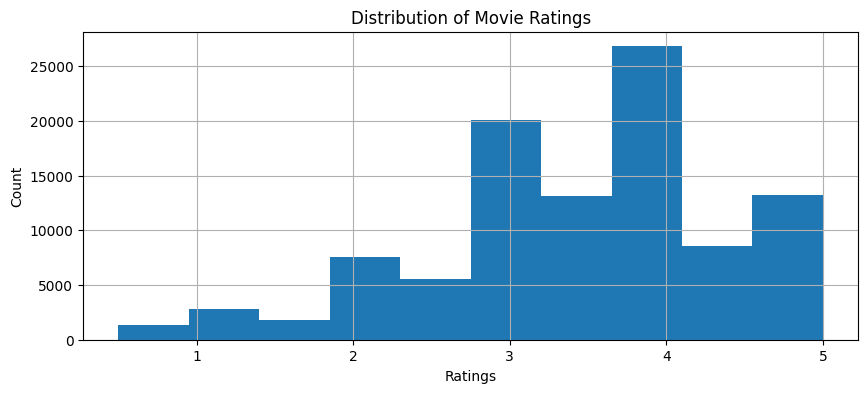

In [276]:
plt.figure(figsize = (10,4))
movie_data['rating'].hist(bins = 10)
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.title('Distribution of Movie Ratings')
plt.show()

1. How many unique users this dataset have?
2. Which movie get the maximum rating? 
3. Find the top 10 highest avg rated movies?
4. Find top 10 highest no. of rating given to a movies?
5. Find top 10 users who gave the highest number of ratings?

In [277]:
movie_data.head()

,movieId,title,userId,rating
0,1,Toy Story (1995),1,4.0
1,1,Toy Story (1995),5,4.0
2,1,Toy Story (1995),7,4.5
3,1,Toy Story (1995),15,2.5
4,1,Toy Story (1995),17,4.5


In [278]:
print(f'There are {movie_data['userId'].nunique()} users who submit their individual ratings to the movies')

There are 610 users who submit their individual ratings to the movies


In [279]:
print(f'{movie_data.groupby('title').count()['rating'].sort_values(ascending = False).reset_index()['title'].iloc[0]} got the maximum number of ratings with a number of {movie_data.groupby('title').count()['rating'].sort_values(ascending = False).reset_index()['rating'].iloc[0]} submissions')

Forrest Gump (1994) got the maximum number of ratings with a number of 329 submissions


In [280]:
print("Top 10 highest average rated movies are :- \n")
for i in movie_data.groupby('title').mean()['rating'].reset_index().sort_values(by = 'rating', ascending = False).head()['title']:
    print(i)

Top 10 highest average rated movies are :- 

Karlson Returns (1970)
Zeitgeist: Moving Forward (2011)
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)
Dragons: Gift of the Night Fury (2011)
12 Angry Men (1997)


In [281]:
print("Top 10 highest no of rated movies by users are :- \n")
for movie_name in movie_data.groupby('title').count()['rating'].reset_index(name = 'no_of_ratings').sort_values(by = 'no_of_ratings', ascending = False).head(10)['title']:
    print(movie_name)

Top 10 highest no of rated movies by users are :- 

Forrest Gump (1994)
Shawshank Redemption, The (1994)
Pulp Fiction (1994)
Silence of the Lambs, The (1991)
Matrix, The (1999)
Star Wars: Episode IV - A New Hope (1977)
Jurassic Park (1993)
Braveheart (1995)
Terminator 2: Judgment Day (1991)
Schindler's List (1993)


In [282]:
print("Top 10 users who gave maximum number of ratings :- \n") 
movie_data.groupby('userId').count()['movieId'].reset_index(name = 'no_of_ratings').sort_values(by = 'no_of_ratings', ascending = False).head(10)

Top 10 users who gave maximum number of ratings :- 



,userId,no_of_ratings
413,414,2698
598,599,2478
473,474,2108
447,448,1864
273,274,1346
609,610,1302
67,68,1260
379,380,1218
605,606,1115
287,288,1055


We going to buil the system on the basis of how much does each user rated the movies
1. Considering those users who gave minumum 100 number of ratings and will not consider the movies who got below than 20 no of ratings

In [283]:
x = movie_data.groupby('userId').count()['rating'] >= 100
experienced_users  = x[x].index

In [284]:
filtered_data = movie_data[movie_data['userId'].isin(experienced_users)]

In [285]:
y = filtered_data.groupby('title').count()['rating'] >= 20
considerable_movies = y[y].index

In [286]:
final_rating = filtered_data[filtered_data['title'].isin(considerable_movies)]
final_rating

,movieId,title,userId,rating
0,1,Toy Story (1995),1,4.0
2,1,Toy Story (1995),7,4.5
3,1,Toy Story (1995),15,2.5
4,1,Toy Story (1995),17,4.5
5,1,Toy Story (1995),18,3.5
...,...,...,...,...
100222,166528,Rogue One: A Star Wars Story (2016),567,1.0
100223,166528,Rogue One: A Star Wars Story (2016),586,4.5
100224,166528,Rogue One: A Star Wars Story (2016),596,5.0
100225,166528,Rogue One: A Star Wars Story (2016),599,3.0


In [287]:
final_rating.duplicated().sum()

np.int64(0)

In [288]:
pt = final_rating.pivot_table(index = 'title', columns = 'userId', values = 'rating')


In [289]:
pt.shape

(1147, 248)

In [290]:
pt.fillna(0, inplace = True)

In [291]:
pt.sample(10)

userId,1,4,6,7,10,15,17,18,19,20,...,600,601,602,603,604,605,606,607,608,610
title,,,,,,,,,,,,,,,,,,,,,
Cool Runnings (1993),0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5,3.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.5,0.0
"Silence of the Lambs, The (1991)",4.0,5.0,4.0,5.0,0.0,0.0,4.5,4.5,0.0,0.0,...,4.0,0.0,5.0,5.0,5.0,0.0,4.5,5.0,4.0,4.5
Wallace & Gromit in The Curse of the Were-Rabbit (2005),0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
"Evil Dead, The (1981)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5,5.0
Big (1988),4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,4.0,0.0,0.0,3.0,0.0,4.5,3.0,4.0,2.5,0.0
Broken Arrow (1996),0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,4.0,0.0,0.0,0.0,2.0,3.5
Ferris Bueller's Day Off (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5,5.0,0.0,...,4.0,0.0,0.0,4.0,0.0,0.0,0.0,3.0,4.0,3.5
"Fugitive, The (1993)",5.0,5.0,5.0,0.0,0.0,0.0,0.0,3.5,4.0,0.0,...,3.0,0.0,5.0,3.0,0.0,0.0,0.0,5.0,3.0,4.5
Multiplicity (1996),0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [292]:
from sklearn.metrics.pairwise import cosine_similarity

In [293]:
similarity_score = cosine_similarity(pt)


In [294]:
similarity_score.shape

(1147, 1147)

In [359]:
def recommend(movie_name):

    movie_name = movie_name.lower().strip()

    # partial movie matching
    matched_movies = [

        movie for movie in pt.index

        if movie_name in movie.lower()

    ]

    # if no movie found
    if len(matched_movies) == 0:

        return ["Movie not found in dataset"]

    # first matched movie
    selected_movie = matched_movies[0]

    # movie index
    index = np.where(
        pt.index == selected_movie
    )[0][0]

    # similarity scores
    similar = sorted(

        enumerate(similarity_score[index]),

        key=lambda x: x[1],

        reverse=True

    )[1:6]

    # recommendations
    recommendations = [

        pt.index[movie[0]]

        for movie in similar

    ]

    return recommendations

In [361]:
print(recommend('WarGames'))

['Spaceballs (1987)', 'Spy Game (2001)', 'Dark City (1998)', 'Gremlins (1984)', 'Indiana Jones and the Temple of Doom (1984)']


In [352]:
import pickle

with open('pt.pkl', 'wb') as file:
    pickle.dump(pt, file)

with open('score.pkl', 'wb') as file:
    pickle.dump(similarity_score, file)

In [358]:
pt.index[0].replace("(", "").replace(")", "")[]

'500 Days of Summer 2009'